## Import des bibliothèques et des données

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maso0dahmed/football-players-data")

print("Path to dataset files:", path)

100%|██████████| 1.24M/1.24M [00:00<00:00, 75.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/maso0dahmed/football-players-data/versions/1


In [ ]:
data_path = os.path.join(path, 'fifa_players.csv') # Assuming the main data file is named 'epl_players_20_21.csv'

In [ ]:
%xmode Plain
df = pd.read_csv(data_path)


Exception reporting mode: Plain


## Des informations globales sur les données

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null 

In [ ]:
print("Nombre de d'enregistrement ", df.shape[0])
print("Nombre de colonnes ",df.shape[1])

Nombre de d'enregistrement  17954
Nombre de colonnes  51


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,17954.0,2.556545e+01,4.705708e+00,17.0,22.00,25.00,29.00,4.600000e+01
height_cm,17954.0,1.749469e+02,1.402945e+01,152.4,154.94,175.26,185.42,2.057400e+02
weight_kgs,17954.0,7.530105e+01,7.083684e+00,49.9,69.90,74.80,79.80,1.102000e+02
overall_rating,17954.0,6.624017e+01,6.963730e+00,47.0,62.00,66.00,71.00,9.400000e+01
potential,17954.0,7.143093e+01,6.131339e+00,48.0,67.00,71.00,75.00,9.500000e+01
value_euro,17699.0,2.479280e+06,5.687014e+06,10000.0,325000.00,700000.00,2100000.00,1.105000e+08
wage_euro,17708.0,9.902135e+03,2.199559e+04,1000.0,1000.00,3000.00,9000.00,5.650000e+05
international_reputation(1-5),17954.0,1.111674e+00,3.921679e-01,1.0,1.00,1.00,1.00,5.000000e+00
weak_foot(1-5),17954.0,2.945695e+00,6.636915e-01,1.0,3.00,3.00,3.00,5.000000e+00
skill_moves(1-5),17954.0,2.361034e+00,7.632226e-01,1.0,2.00,2.00,3.00,5.000000e+00


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
national_jersey_number,17097
national_team_position,17097
national_rating,17097
national_team,17097
release_clause_euro,1837
value_euro,255
wage_euro,246
name,0
shot_power,0
ball_control,0


In [ ]:
df.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [ ]:
df.columns

Index(['name', 'full_name', 'birth_date', 'age', 'height_cm', 'weight_kgs',
       'positions', 'nationality', 'overall_rating', 'potential', 'value_euro',
       'wage_euro', 'preferred_foot', 'international_reputation(1-5)',
       'weak_foot(1-5)', 'skill_moves(1-5)', 'body_type',
       'release_clause_euro', 'national_team', 'national_rating',
       'national_team_position', 'national_jersey_number', 'crossing',
       'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'dribbling', 'curve', 'freekick_accuracy', 'long_passing',
       'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions',
       'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
       'aggression', 'interceptions', 'positioning', 'vision', 'penalties',
       'composure', 'marking', 'standing_tackle', 'sliding_tackle'],
      dtype='object')

## Nettoyage et explotation des donnée <br><br>

### Catégorisations des données
- **Informations personnelles** :
 - name
 - full_name
 - birth_date
 - age
 - height_cm
 - weight_kgs
 - nationality
 - body_type

- **Données contractuelles et économiques** :
 - value_euro
 - wage_euro
 - release_clause_euro

- **Données de performance globale:**
 - overall_rating
 - potential
 - international_reputation(1-5)
 - national_rating

- **Position et rôle:**
 - positions
 - national_team
 - national_team_position
 - national_jersey_number

- **Compétences spécifiques (Skills)**:
 - weak_foot(1-5)
 - skill_moves(1-5)
 - preferred_foot
 - crossing
 - finishing
 - heading_accuracy
 - short_passing
 - volleys
 - dribbling
 - curve
 - freekick_accuracy
 - long_passing
 - ball_control

- **Données physiques et mentales** :
 - acceleration
 - sprint_speed
 - agility
 - reactions
 - balance
 - shot_power
 - jumping
 - stamina
 - strength
 - composure

Avec toutes ses différentes catégories trouvées nous allons faire des analyses descriptives, des prédictions, aller plus loin dans les analyses et créations de visualisation. <br>
L'objectif est de répondre à plusieurs problematiques. <br>
Ici les fonctions qui seront créées si l'on veux avoir des informations sur les joueur, l'utilisateur aura la possibilité d'indique le nombre de joueur qu'il veut voir. Exemple: les 4 joueurs plus jeunes

### **1. Exploration des données personnelles**
- **Quel est le joueur le plus âgé/le plus jeune du dataset ?**
- **Quelle est la répartition des nationalités parmi les joueurs ?**
- **Quelle est la répartition des tailles et poids des joueurs ?**
- **Y a-t-il une corrélation entre l'âge d'un joueur et sa valeur marchande (`value_euro`) ?**
- **Quelle est la proportion des joueurs qui utilisent le pied gauche ou droit (`preferred_foot`) ?**
- **Quelle est la distribution des réputations internationales (`international_reputation(1-5)`) ?**


In [ ]:
def Joueur_Jeune (nbre):
  resultat = df[['full_name','age','nationality']].sort_values(by = 'age', ascending=True).head(nbre)
  if nbre == 1:
    print('Voici le resultat du jeune joueur de notre dataset')
  else:
    print('Voici le resultat des ', nbre,'Jeunes joueurs de notre dataset')
  return resultat

In [ ]:
Joueur_Jeune(3)

Voici le resultat des  3 Jeunes joueurs de notre dataset


,full_name,age,nationality
9511,Adil Taoui,17,France
5637,Gilbert Fuentes,17,United States
5636,Dylan Mbayo,17,Belgium


In [ ]:
def Joueur_plus_age (nbre):
  resultat = df[['full_name','age', 'nationality']].sort_values(by = 'age', ascending=False).head(nbre)
  if nbre == 1:
    print('Voici le resultat du plus agé joueur de notre dataset')
  else:
    print('Voici le resultat des ', nbre,'joueurs les plus agé de notre dataset')
  return resultat

In [ ]:
Joueur_plus_age(1)

Voici le resultat du plus agé joueur de notre dataset


,full_name,age,nationality
1304,Óscar Pérez Rojas,46,Mexico


In [ ]:
df_nbr_nation = df.groupby('nationality', dropna=True).size().sort_values(ascending=False)

In [ ]:
df_nbr_nation = df_nbr_nation.reset_index()
df_nbr_nation = df_nbr_nation.rename(columns = {0:'Nombre'})
df_nbr_nation

,nationality,Nombre
0,England,1658
1,Germany,1199
2,Spain,1070
3,France,925
4,Argentina,904
...,...,...
155,Guam,1
156,New Caledonia,1
157,Indonesia,1
158,St Lucia,1


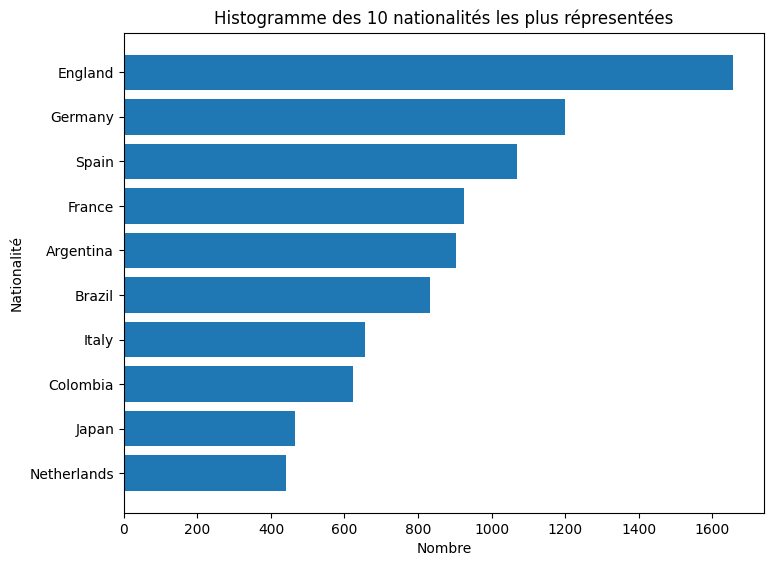

In [ ]:
df_nation_10 = df_nbr_nation.head(10).sort_values(by = 'Nombre', ascending=True)
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.barh(df_nation_10['nationality'], df_nation_10['Nombre'])
plt.title("Histogramme des 10 nationalités les plus répresentées")
plt.ylabel('Nationalité')  # Titre de l'axe y
plt.xlabel('Nombre')  # Titre de l'axe x
plt.show()  # Affichage d'une courbe

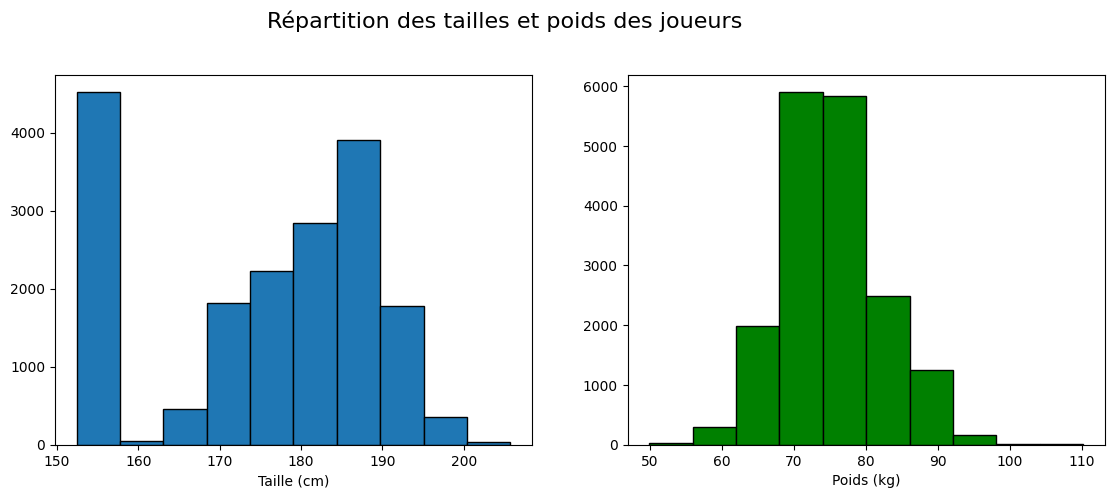

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plt.suptitle('Répartition des tailles et poids des joueurs', fontsize=16)

ax1.hist(df['height_cm'],edgecolor='black')
ax2.hist(df['weight_kgs'], color='green',edgecolor='black')

ax1.set_xlabel('Taille (cm)')
ax2.set_xlabel('Poids (kg)')

plt.subplots_adjust(left=0.2, wspace=0.2, top=0.85) # ajuster la position et l'espacement des graphes
plt.show()

In [ ]:
# Création de table de réference des positions
positions_reference = {
    "GK": "Goalkeeper (Gardien de but)",
    "CB": "Centre Back (Défenseur central)",
    "LB": "Left Back (Arrière gauche)",
    "RB": "Right Back (Arrière droit)",
    "LWB": "Left Wing Back (Latéral gauche offensif)",
    "RWB": "Right Wing Back (Latéral droit offensif)",
    "CDM": "Central Defensive Midfielder (Milieu défensif)",
    "CM": "Central Midfielder (Milieu central)",
    "CAM": "Central Attacking Midfielder",
    "LM": "Left Midfielder (Milieu gauche)",
    "RM": "Right Midfielder (Milieu droit)",
    "LW": "Left Wing (Ailier gauche)",
    "RW": "Right Wing (Ailier droit)",
    "CF": "Centre Forward (Attaquant de soutien)",
    "ST": "Striker (Avant-centre)",
    "LF": "Left Forward (Attaquant gauche)",
    "RF": "Right Forward (Attaquant droit)",
    "CD": "Centre Defender (Défenseur central polyvalent)",
    "CFM": "Centre Forward Midfielder (Milieu offensif central)"
}

positions_df = pd.DataFrame(list(positions_reference.items()), columns=["Position", "Description"])

In [ ]:
def hist_position(position):
    """
    Affiche un histogramme de la répartition des tailles et poids des joueurs pour une position donnée.
    Args:
        position (str): Le code de la position à analyser (par exemple 'GK', 'ST').
    """
    df_position = df[df.positions.str.contains(position, na=False)]

    # Filtrer la table des descriptions pour obtenir la description associée
    position_info = positions_df[positions_df['Position'] == position]

    if position_info.empty:
        print(f"Position '{position}' non trouvée dans le DataFrame des descriptions.")
        return
    description = position_info["Description"].iloc[0]
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    plt.suptitle(f"Répartition des tailles et poids des joueurs occupant le poste : {description}", fontsize=16)
    ax1.hist(df_position['height_cm'].dropna(), bins=20, color='blue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Taille (cm)')
    ax1.set_ylabel('Nombre de joueurs')
    ax1.set_title('Distribution de la taille')
    ax2.hist(df_position['weight_kgs'].dropna(), bins=20, color='green', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Poids (kg)')
    ax2.set_ylabel('Nombre de joueurs')
    ax2.set_title('Distribution du poids')
    plt.subplots_adjust(left=0.1, wspace=0.4, top=0.85)
    plt.show()


Exception reporting mode: Verbose


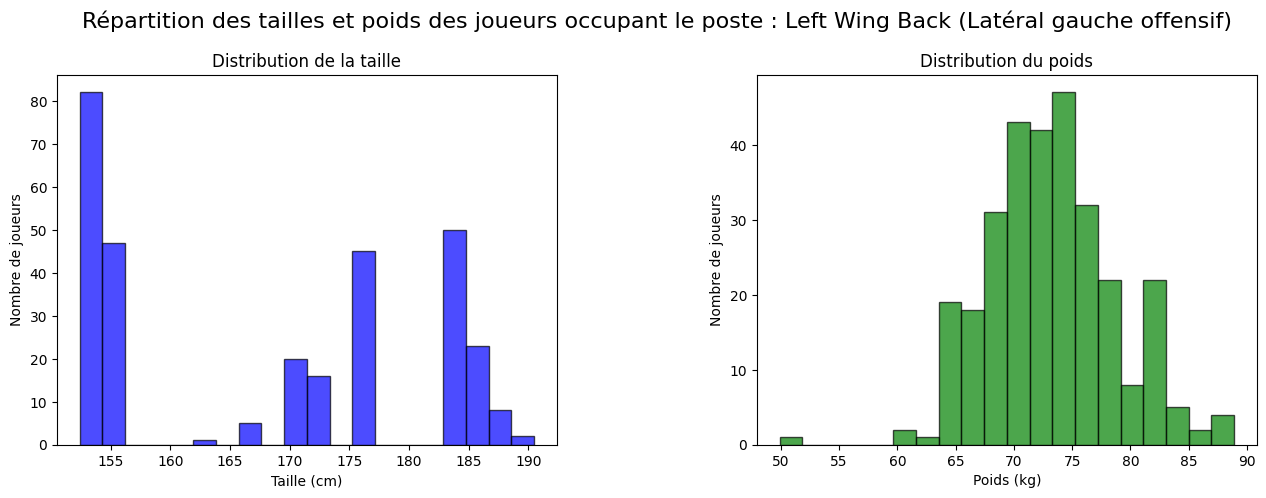

In [ ]:
%xmode verbose
hist_position('LWB')

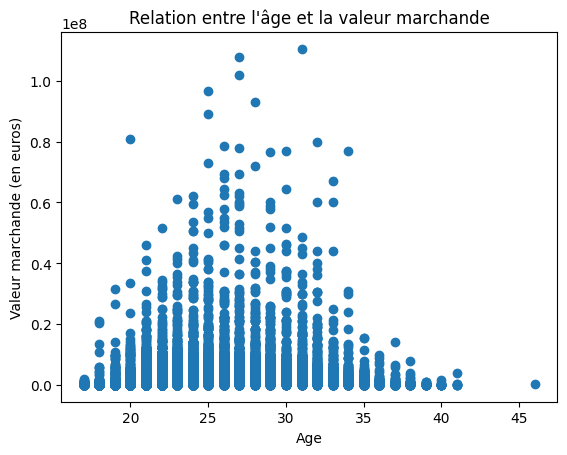

In [ ]:
df_valeur_euro = df.dropna(subset=['value_euro'])
plt.scatter(df_valeur_euro['age'],df_valeur_euro['value_euro'])
plt.xlabel('Age')
plt.ylabel('Valeur marchande (en euros)')
plt.title('Relation entre l\'âge et la valeur marchande')
plt.show()

In [ ]:
pd_preferred_foot = df.groupby('preferred_foot').size()
pd_preferred_foot = pd_preferred_foot.reset_index()
pd_preferred_foot = pd_preferred_foot.rename(columns = {0:'Nombre'})
pd_preferred_foot

,preferred_foot,Nombre
0,Left,4173
1,Right,13781


In [ ]:
df['international_reputation(1-5)'] = df['international_reputation(1-5)'].astype(str)
pd_international_reputation = df.groupby('international_reputation(1-5)').size()
pd_international_reputation = pd_international_reputation.reset_index()
pd_international_reputation = pd_international_reputation.rename(columns = {0:'Nombre'})
pd_international_reputation

,international_reputation(1-5),Nombre
0,1,16370
1,2,1226
2,3,301
3,4,51
4,5,6


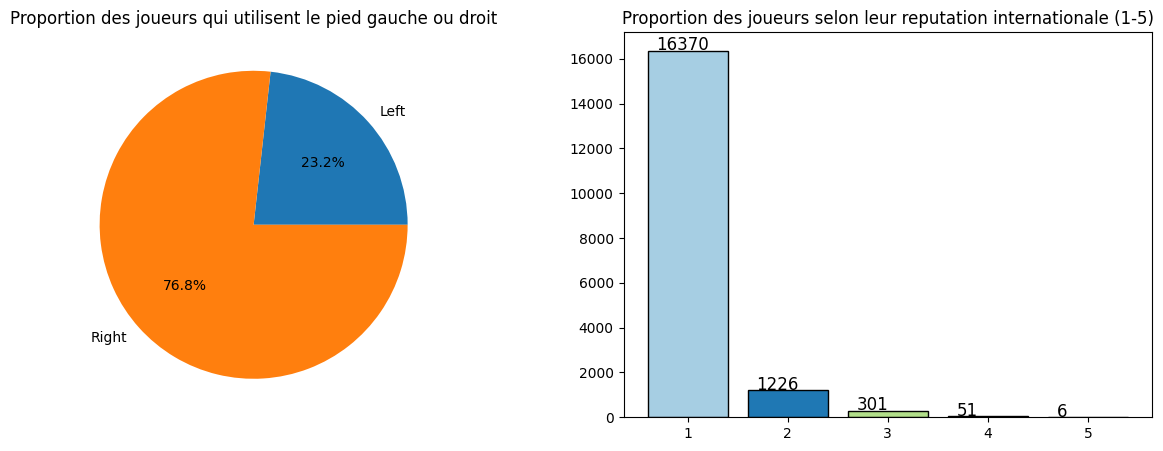

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
col_map = plt.get_cmap('Paired')
ax1.pie(pd_preferred_foot['Nombre'], labels=pd_preferred_foot['preferred_foot'], autopct="%1.1f%%")
pl = ax2.bar(pd_international_reputation['international_reputation(1-5)'],pd_international_reputation['Nombre'],color=col_map.colors, edgecolor='k',
        linewidth=1)
for bar in pl:
    plt.annotate(bar.get_height(),
                 xy=(bar.get_x()+0.09, bar.get_height()+15),
                     fontsize=12)
ax1.set_title('Proportion des joueurs qui utilisent le pied gauche ou droit')
ax2.set_title('Proportion des joueurs selon leur reputation internationale (1-5)')
plt.show()

In [ ]:
# les 10 joueurs les plus populaires
df[['full_name','international_reputation(1-5)', 'age', 'nationality', 'wage_euro','value_euro','release_clause_euro','positions']].sort_values(by='international_reputation(1-5)', ascending=False).head(50)

,full_name,international_reputation(1-5),age,nationality,wage_euro,value_euro,release_clause_euro,positions
0,Lionel Andrés Messi Cuccittini,5,31,Argentina,565000.0,110500000.0,226500000.0,"CF,RW,ST"
8,Manuel Neuer,5,32,Germany,130000.0,38000000.0,62700000.0,GK
17943,Neymar da Silva Santos Junior,5,27,Brazil,290000.0,108000000.0,199800000.0,"LW,CAM"
17938,Luis Alberto Suárez Díaz,5,32,Uruguay,455000.0,80000000.0,164000000.0,ST
46,Zlatan Ibrahimović,5,37,Sweden,15000.0,14000000.0,21000000.0,ST
17944,Cristiano Ronaldo dos Santos Aveiro,5,34,Portugal,405000.0,77000000.0,127100000.0,"ST,LW"
17864,David Olatukunbo Alaba,4,26,Austria,98000.0,30500000.0,52600000.0,"LB,CB"
17935,Robert Lewandowski,4,30,Poland,205000.0,77000000.0,127100000.0,ST
17717,Petr Čech,4,36,Czech Republic,60000.0,3000000.0,5700000.0,GK
17882,Ángel Fabián Di María Hernández,4,31,Argentina,140000.0,36500000.0,67500000.0,"RW,LW"


### **2. Performance des joueurs**
- **Quels sont les joueurs ayant les meilleures compétences globales (`overall_rating`) ?**
- **Quel est le joueur avec le meilleur potentiel (`potential`) ?**
- **Quels sont les attributs techniques les plus élevés pour chaque position ?**  
  - Exemple : Pour les attaquants (positions : "ST"), quels sont les joueurs avec la meilleure précision de tirs (`finishing`) ?
- **Quels joueurs ont les meilleures compétences en dribble, passe, ou vitesse (`dribbling`, `short_passing`, `sprint_speed`) ?**
- **Quel est le classement des meilleurs gardiens (GK) en fonction des attributs liés à leur position ?**
- **Existe-t-il des joueurs exceptionnels avec des "pieds faibles" (`weak_foot(1-5)`) ou des "gestes techniques" élevés (`skill_moves(1-5)`) ?**

{'Afghanistan': [4021, 7022, 9414], 'Albania': [1088, 1094, 2128, 2184, 2202, 2231, 2257, 2509, 3322, 3339, 3651, 4180, 4228, 4290, 4332, 5851, 5941, 6935, 7268, 7879, 9122, 9807, 10068, 10807, 10882, 11000, 12268, 12413, 12784, 12816, 13422, 13534, 13607, 14502, 14847, 15076, 15231, 15261, 15936, 15961, 17629, 17781], 'Algeria': [138, 397, 406, 846, 848, 924, 1142, 1287, 1641, 1671, 2222, 2406, 2422, 2692, 3216, 6758, 7283, 8920, 9081, 10229, 10251, 10275, 10669, 11019, 11313, 12402, 12702, 13024, 13025, 13080, 13208, 13350, 13464, 13596, 13698, 13944, 14043, 14217, 14243, 14891, 14973, 15199, 15330, 15495, 15614, 15751, 16512, 16558, 16559, 16666, 16699, 16729, 16981, 16990, 17386, 17458, 17465, 17694, 17884, 17893], 'Andorra': [3655], 'Angola': [906, 1343, 7630, 7925, 9933, 10313, 11801, 13437, 14690, 15117, 15119, 15670, 17388], 'Antigua & Barbuda': [6647, 7158, 9165, 13171], 'Argentina': [0, 7, 15, 18, 31, 71, 82, 146, 147, 173, 174, 202, 213, 214, 275, 278, 304, 306, 310, 314, 34

---

### **3. Analyse financière**
- **Quels joueurs ont la plus grande valeur marchande (`value_euro`) ?**
- **Quels joueurs ont le salaire hebdomadaire (`wage_euro`) le plus élevé ?**
- **Quelle est la relation entre le salaire (`wage_euro`) et la valeur marchande (`value_euro`) ?**
- **Y a-t-il une relation entre la clause libératoire (`release_clause_euro`) et les autres attributs financiers ?**
- **Quels pays/nationalités produisent les joueurs les plus chers ?**
- **Quels joueurs sont "surévalués" (salaire élevé mais faible performance globale) ou "sous-évalués" (performance élevée mais faible salaire) ?**

---

### **4. Comparaisons et classements**
- **Quels clubs/nationalités ont le plus grand nombre de joueurs dans le top 100 des meilleurs joueurs (selon `overall_rating`) ?**
- **Quel est le joueur le plus rentable (rapport valeur/salaire : `value_euro` / `wage_euro`) ?**
- **Quels sont les meilleurs joueurs pour chaque position (`positions`) ?**
- **Quels clubs/nationalités dominent dans certaines catégories (vitesse, dribble, tir) ?**
- **Existe-t-il des joueurs "polyvalents" capables de jouer dans plusieurs positions (`positions`) ?**

---

### **5. Visualisation des données**
- **Quelle est la distribution des valeurs des joueurs (`value_euro`) dans différentes catégories d'âge ?**
- **Quels attributs sont fortement corrélés avec la performance globale (`overall_rating`) ?**
- **Comment les compétences techniques (comme `dribbling`, `finishing`, `short_passing`) évoluent-elles en fonction de l'âge ?**
- **Quelle est la répartition des salaires (`wage_euro`) pour les joueurs dans chaque position ?**

---

### **6. Questions prédictives et machine learning**
- **Peut-on prédire la performance globale (`overall_rating`) d’un joueur en fonction de ses attributs techniques (par exemple, `dribbling`, `finishing`, `sprint_speed`) ?**
- **Quels facteurs influencent le plus la valeur marchande (`value_euro`) d’un joueur ?**
- **Peut-on segmenter les joueurs en groupes similaires à l’aide du clustering (par exemple, K-means) en fonction de leurs attributs techniques ?**
- **Peut-on prédire le salaire (`wage_euro`) en fonction des autres variables (comme `value_euro`, `potential`, etc.) ?**
- **Quels attributs permettent de distinguer les joueurs "stars" (haute réputation internationale, forte valeur) des joueurs ordinaires ?**

---

### **7. Questions sur le contrôle de qualité et gestion**
- **Les joueurs ayant une forte réputation internationale (`international_reputation`) sont-ils réellement les meilleurs selon leurs performances techniques ?**
- **Existe-t-il des disparités ou incohérences dans les données ? Par exemple :**
  - Des joueurs avec des valeurs très élevées mais de faibles compétences globales.
  - Des joueurs avec une faible clause libératoire mais une haute réputation.

---

### **8. Projets combinés**
Pour créer des projets plus avancés, vous pouvez combiner plusieurs de ces questions :
1. **Analyse des "stars montantes" :** Trouver les jeunes joueurs (< 21 ans) avec un potentiel élevé (`potential`) et un faible coût (`value_euro`), et les recommander pour une équipe.
2. **Modèle prédictif :** Construire un modèle pour prédire la valeur d'un joueur (`value_euro`) en fonction de ses caractéristiques (techniques, âge, réputation, etc.).
3. **Clustering des joueurs :** Classer les joueurs en différents groupes (par exemple, "attaquants rapides", "milieux créatifs", "défenseurs physiques") pour identifier des profils spécifiques.
4. **Analyse de rentabilité :** Comparer les joueurs en termes de salaire/performance pour recommander des choix rentables aux clubs.